In [1]:
# Dataset Class
#MAIN
import os
import numpy as np
import torch

from PIL import Image
from torch.utils.data import Dataset


class ISICDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(
            [
                f for f in os.listdir(image_dir)
                if f.endswith(".jpg")
            ]
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        mask_name = image_name.replace(
            ".jpg",
            "_segmentation.png"
        )

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        # Load Image & Mask

        image = Image.open(image_path).resize((256, 256))
        mask = Image.open(mask_path).resize((256, 256))

        # Convert to NumPy

        image = np.array(image) / 255.0

        mask = np.array(mask)
        mask = (mask > 0).astype(np.uint8)

        # -------------------------
        # Convert Image to Tensor
        # -------------------------

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        # (256,256,3) -> (3,256,256)

        image = image.permute(
            2,
            0,
            1
        )

        # -------------------------
        # Convert Mask to Tensor
        # -------------------------

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        # (256,256) -> (1,256,256)

        mask = mask.unsqueeze(0)

        return image, mask
    
dataset = ISICDataset(
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images",
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\masks"
)

print("Dataset Created")
print(len(dataset))

image, mask = dataset[0]

print(image.shape)
print(mask.shape)

print(type(image))
print(type(mask))

Dataset Created
2594
torch.Size([3, 256, 256])
torch.Size([1, 256, 256])
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [10]:
#BATCH LOADER MAIN
#Create DataLoader

from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

print("DataLoader Ready")

#Test Batch

images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

DataLoader Ready
torch.Size([16, 3, 256, 256])
torch.Size([16, 1, 256, 256])


In [11]:
#data loader
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

print("DataLoader Created")

images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

DataLoader Created
torch.Size([16, 3, 256, 256])
torch.Size([16, 1, 256, 256])


In [12]:
image, mask = dataset[0]

print(image.shape)
print(mask.shape)

torch.Size([3, 256, 256])
torch.Size([1, 256, 256])


In [13]:
dataset[0]
dataset[1]
dataset[2]

(tensor([[[0.9255, 0.9020, 0.9059,  ..., 0.8980, 0.8941, 0.9137],
          [0.8980, 0.8667, 0.8627,  ..., 0.8549, 0.8471, 0.8784],
          [0.9020, 0.8745, 0.8667,  ..., 0.8588, 0.8588, 0.8824],
          ...,
          [0.9137, 0.8902, 0.8902,  ..., 0.8745, 0.8745, 0.9020],
          [0.9098, 0.8902, 0.8902,  ..., 0.8588, 0.8667, 0.8902],
          [0.9294, 0.9216, 0.9216,  ..., 0.8902, 0.8824, 0.9137]],
 
         [[0.9216, 0.8980, 0.9020,  ..., 0.9020, 0.8980, 0.9176],
          [0.8941, 0.8627, 0.8588,  ..., 0.8588, 0.8510, 0.8824],
          [0.8980, 0.8706, 0.8627,  ..., 0.8627, 0.8627, 0.8863],
          ...,
          [0.9176, 0.8941, 0.8941,  ..., 0.8784, 0.8784, 0.9059],
          [0.9137, 0.8941, 0.8941,  ..., 0.8627, 0.8706, 0.8941],
          [0.9333, 0.9255, 0.9255,  ..., 0.8941, 0.8863, 0.9176]],
 
         [[0.9412, 0.9137, 0.9176,  ..., 0.9137, 0.9137, 0.9294],
          [0.9137, 0.8863, 0.8863,  ..., 0.8784, 0.8745, 0.8980],
          [0.9176, 0.8941, 0.8863,  ...,

In [14]:
dataset = ISICDataset(
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images",
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\masks"
)

print("Dataset Created")
print(len(dataset))

Dataset Created
2594


In [15]:
image, mask = dataset[0]

print("Image Shape:", image.shape)
print("Mask Shape:", mask.shape)

Image Shape: (256, 256, 3)
Mask Shape: (256, 256)


In [16]:
#dataset class
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class ISICDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(
            [f for f in os.listdir(image_dir)
             if f.endswith(".jpg")]
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        mask_name = image_name.replace(
            ".jpg",
            "_segmentation.png"
        )

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        image = Image.open(image_path).resize((256,256))
        mask = Image.open(mask_path).resize((256,256))

        image = np.array(image) / 255.0

        mask = np.array(mask)
        mask = (mask > 0).astype(np.uint8)

        return image, mask


In [17]:

from sklearn.model_selection import train_test_split
import os

image_dir = r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images"

image_files = [
    f for f in os.listdir(image_dir)
    if f.endswith(".jpg")
]

train_files, val_files = train_test_split(
    image_files,
    test_size=0.2,
    random_state=42
)

print("Train Images:", len(train_files))
print("Validation Images:", len(val_files))

Train Images: 2075
Validation Images: 519


In [18]:
#convert mask to binary
import numpy as np

mask_array = np.array(mask_resized)

print("Before Conversion:")
print(np.unique(mask_array))

#after conversion to binary
mask_binary = (mask_array > 0).astype(np.uint8)

print("After Conversion:")
print(np.unique(mask_binary))

NameError: name 'mask_resized' is not defined

In [ ]:
#normalization of images in the dataset
import numpy as np

img_array = np.array(image_resized)

print("Before Normalization")
print("Min:", img_array.min())
print("Max:", img_array.max())

img_normalized = img_array / 255.0

print("After Normalization")
print("Min:", img_normalized.min())
print("Max:", img_normalized.max())

Before Normalization
Min: 20
Max: 255
After Normalization
Min: 0.0784313725490196
Max: 1.0


In [ ]:
#stage: 2 : data preprocessing
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images\ISIC_0000000.jpg"
)

mask = Image.open(
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\masks\ISIC_0000000_segmentation.png"
)

# Resize

image_resized = image.resize((256,256))
mask_resized = mask.resize((256,256))

print("Original Image:", image.size)
print("Resized Image :", image_resized.size)

print("Original Mask :", mask.size)
print("Resized Mask  :", mask_resized.size)

Original Image: (1022, 767)
Resized Image : (256, 256)
Original Mask : (1022, 767)
Resized Mask  : (256, 256)


In [ ]:
#dataset stastics
import os
from PIL import Image

image_dir = r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images"

widths = []
heights = []

image_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

for file in image_files:
    img = Image.open(os.path.join(image_dir, file))
    w, h = img.size

    widths.append(w)
    heights.append(h)

print("Total Images:", len(image_files))

print("Min Width :", min(widths))
print("Max Width :", max(widths))
print("Average Width :", sum(widths)/len(widths))

print("Min Height :", min(heights))
print("Max Height :", max(heights))
print("Average Height :", sum(heights)/len(heights))

Total Images: 2594
Min Width : 576
Max Width : 6748
Average Width : 3188.2663839629913
Min Height : 540
Max Height : 4499
Average Height : 2166.791441788743


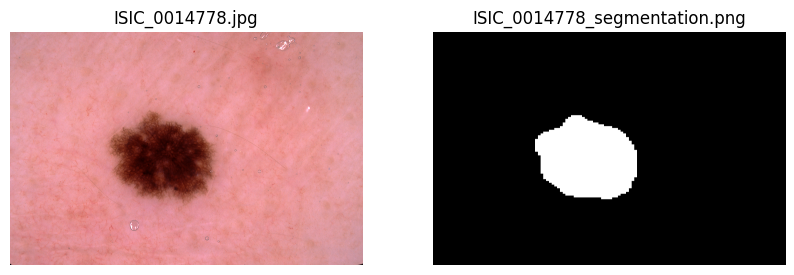

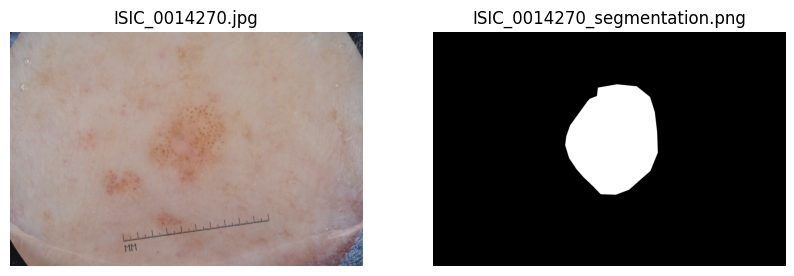

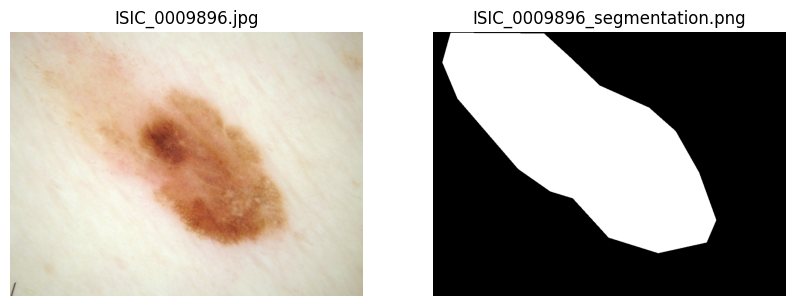

In [ ]:
#random sample visualization of images and masks from the dataset
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

image_dir = r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images"
mask_dir = r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\masks"

image_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

random_samples = random.sample(image_files, 3)

for image_file in random_samples:
    
    image_path = os.path.join(image_dir, image_file)

    mask_file = image_file.replace(".jpg", "_segmentation.png")
    mask_path = os.path.join(mask_dir, mask_file)

    image = Image.open(image_path)
    mask = Image.open(mask_path)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title(image_file)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap="gray")
    plt.title(mask_file)
    plt.axis("off")

    plt.show()

In [ ]:
#binary mask verification
from PIL import Image
import numpy as np

image = Image.open(
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images\ISIC_0000000.jpg"
)

img_array = np.array(image)

print("Shape:", img_array.shape)

Shape: (767, 1022, 3)


In [ ]:
#mask check 
from PIL import Image

mask = Image.open(
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\masks\ISIC_0000000_segmentation.png"
)


print("Mask Size:", mask.size)



Mask Size: (1022, 767)


In [ ]:
#Image Size
from PIL import Image

image = Image.open(
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images\ISIC_0000000.jpg"
)

print("Image Size:", image.size)

Image Size: (1022, 767)


In [ ]:
#stage 1 (dataset exploration) of the project
#total imgs count and total masks count in the dataset
import os

images = [f for f in os.listdir(r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images") if f.endswith(".jpg")]
masks = [f for f in os.listdir(r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\masks") if f.endswith(".png")]

print("Total Images:", len(images))
print("Total Masks:", len(masks))

Total Images: 2594
Total Masks: 2594


In [ ]:
import numpy as np

mask_array = np.array(mask)

print("Shape:", mask_array.shape)
print("Min:", mask_array.min())
print("Max:", mask_array.max())
print("Unique Values:", np.unique(mask_array))

Shape: (767, 1022)
Min: 0
Max: 255
Unique Values: [  0 255]


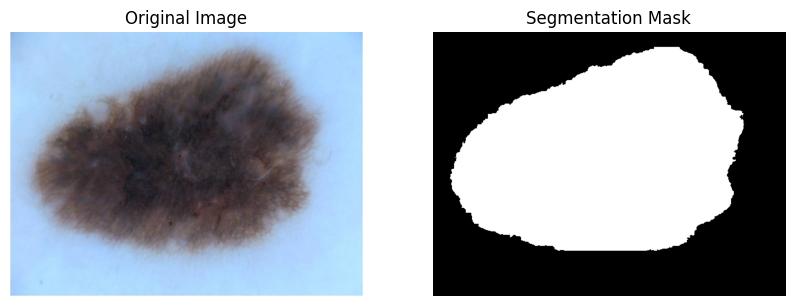

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\Images\ISIC_0000000.jpg"
)

mask = Image.open(
    r"D:\MedTrack-TX\datasets\ISIC2018_TRAIN\masks\ISIC_0000000_segmentation.png"
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

In [ ]:
import numpy as np

mask_array = np.array(mask)

white_pixels = np.sum(mask_array > 0)

print("Lesion Area (pixels):", white_pixels)

Lesion Area (pixels): 368211


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

mask = Image.open(
    r"D:\MedTrack-TX\datasets\ISIC2018_SAMPLE\masks\ISIC_0000000_segmentation.png"
)

plt.figure(figsize=(5,5))
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\MedTrack-TX\\datasets\\ISIC2018_SAMPLE\\masks\\ISIC_0000000_segmentation.png'

In [ ]:
import os

print(os.listdir(r"D:\MedTrack-TX\datasets"))

['Downloads', 'ISIC2018_SAMPLE', 'ISIC2018_TRAIN']


In [ ]:
import os
#len of masks in the dataset
masks = os.listdir(r"D:\MedTrack-TX\datasets\ISIC2018_SAMPLE\masks")

print("Total Masks:", len(masks))
print(masks[:10])

Total Masks: 2596
['ATTRIBUTION.txt', 'ISIC_0000000_segmentation.png', 'ISIC_0000001_segmentation.png', 'ISIC_0000003_segmentation.png', 'ISIC_0000004_segmentation.png', 'ISIC_0000006_segmentation.png', 'ISIC_0000007_segmentation.png', 'ISIC_0000008_segmentation.png', 'ISIC_0000009_segmentation.png', 'ISIC_0000011_segmentation.png']


In [ ]:
import os
#len of images in the dataset
images = os.listdir(r"D:\MedTrack-TX\datasets\ISIC2018_SAMPLE\images")

print("Total Images:", len(images))
print(images[:10])

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\MedTrack-TX\\datasets\\ISIC2018_SAMPLE\\images'

In [ ]:
visit1_area = 1000
visit2_area = 1500

growth = visit2_area - visit1_area
growth_percent = (growth / visit1_area) * 100

print("Growth:", growth)
print("Growth %:", growth_percent)

Growth: 500
Growth %: 50.0


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("MedTrack-TX Dataset Exploration Started 🚀")

MedTrack-TX Dataset Exploration Started 🚀


In [ ]:
print("Hello MedTrack-TX 🚀")

Hello MedTrack-TX 🚀
